# 02 - Exploratory Data Analysis

Trend, seasonality, weekday/hour patterns, missing-period and outlier detection, and cross-category correlation, using the cleaned data loaded into `pharma_sales.db` in the previous notebook.

In [1]:
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

DATA_DIR = Path("../data")
PROCESSED_DIR = DATA_DIR / "processed"
IMAGES_DIR = Path("../images")
IMAGES_DIR.mkdir(exist_ok=True)

conn = sqlite3.connect(PROCESSED_DIR / "pharma_sales.db")
categories = pd.read_sql("SELECT * FROM dim_category", conn)
CODE_TO_NAME = dict(zip(categories["category_code"], categories["category_name"]))
categories

,category_code,category_name
0,M01AB,Anti-inflammatory (acetic acid derivatives)
1,M01AE,Anti-inflammatory (propionic acid derivatives)
2,N02BA,Analgesics - salicylic acid derivatives
3,N02BE,Analgesics - pyrazolones and anilides
4,N05B,Anxiolytics
5,N05C,Hypnotics and sedatives
6,R03,Anti-asthmatic and COPD drugs
7,R06,Antihistamines


In [2]:
def load_granularity(granularity):
    df = pd.read_sql(
        "SELECT sale_date, category_code, units_sold FROM fact_sales WHERE granularity = ?",
        conn, params=(granularity,), parse_dates=["sale_date"]
    )
    df["category_name"] = df["category_code"].map(CODE_TO_NAME)
    return df.sort_values("sale_date").reset_index(drop=True)

monthly = load_granularity("monthly")
weekly = load_granularity("weekly")
daily = load_granularity("daily")
hourly = load_granularity("hourly")

monthly.head()

,sale_date,category_code,units_sold,category_name
0,2014-01-31,M01AB,127.69,Anti-inflammatory (acetic acid derivatives)
1,2014-01-31,R03,112.00,Anti-asthmatic and COPD drugs
2,2014-01-31,N05C,50.00,Hypnotics and sedatives
3,2014-01-31,N05B,354.00,Anxiolytics
4,2014-01-31,N02BE,878.03,Analgesics - pyrazolones and anilides


## Total volume by category

Which drug categories actually drive the business, over the full 2014-2019 window.

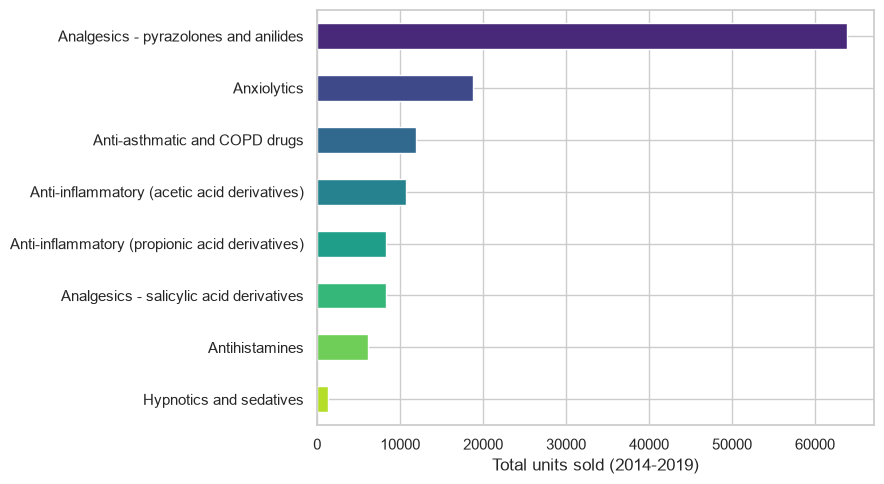

category_name
Analgesics - pyrazolones and anilides             63917.305000
Anxiolytics                                       18791.050000
Anti-asthmatic and COPD drugs                     11933.656250
Anti-inflammatory (acetic acid derivatives)       10681.342083
Anti-inflammatory (propionic acid derivatives)     8306.991250
Analgesics - salicylic acid derivatives            8242.729833
Antihistamines                                     6128.130000
Hypnotics and sedatives                            1283.166667
Name: units_sold, dtype: float64

In [3]:
total_by_category = (
    monthly.groupby("category_name")["units_sold"].sum().sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 5))
total_by_category.plot(kind="barh", ax=ax, color=sns.color_palette("viridis", len(total_by_category)))
ax.set_xlabel("Total units sold (2014-2019)")
ax.set_ylabel("")
ax.invert_yaxis()
fig.tight_layout()
fig.savefig(IMAGES_DIR / "total_volume_by_category.png", dpi=150)
plt.show()

total_by_category

## Trend over time

Monthly series per category, plotted as small multiples so scale differences between categories (e.g. N02BE vs N05C) don't hide each other's shape.

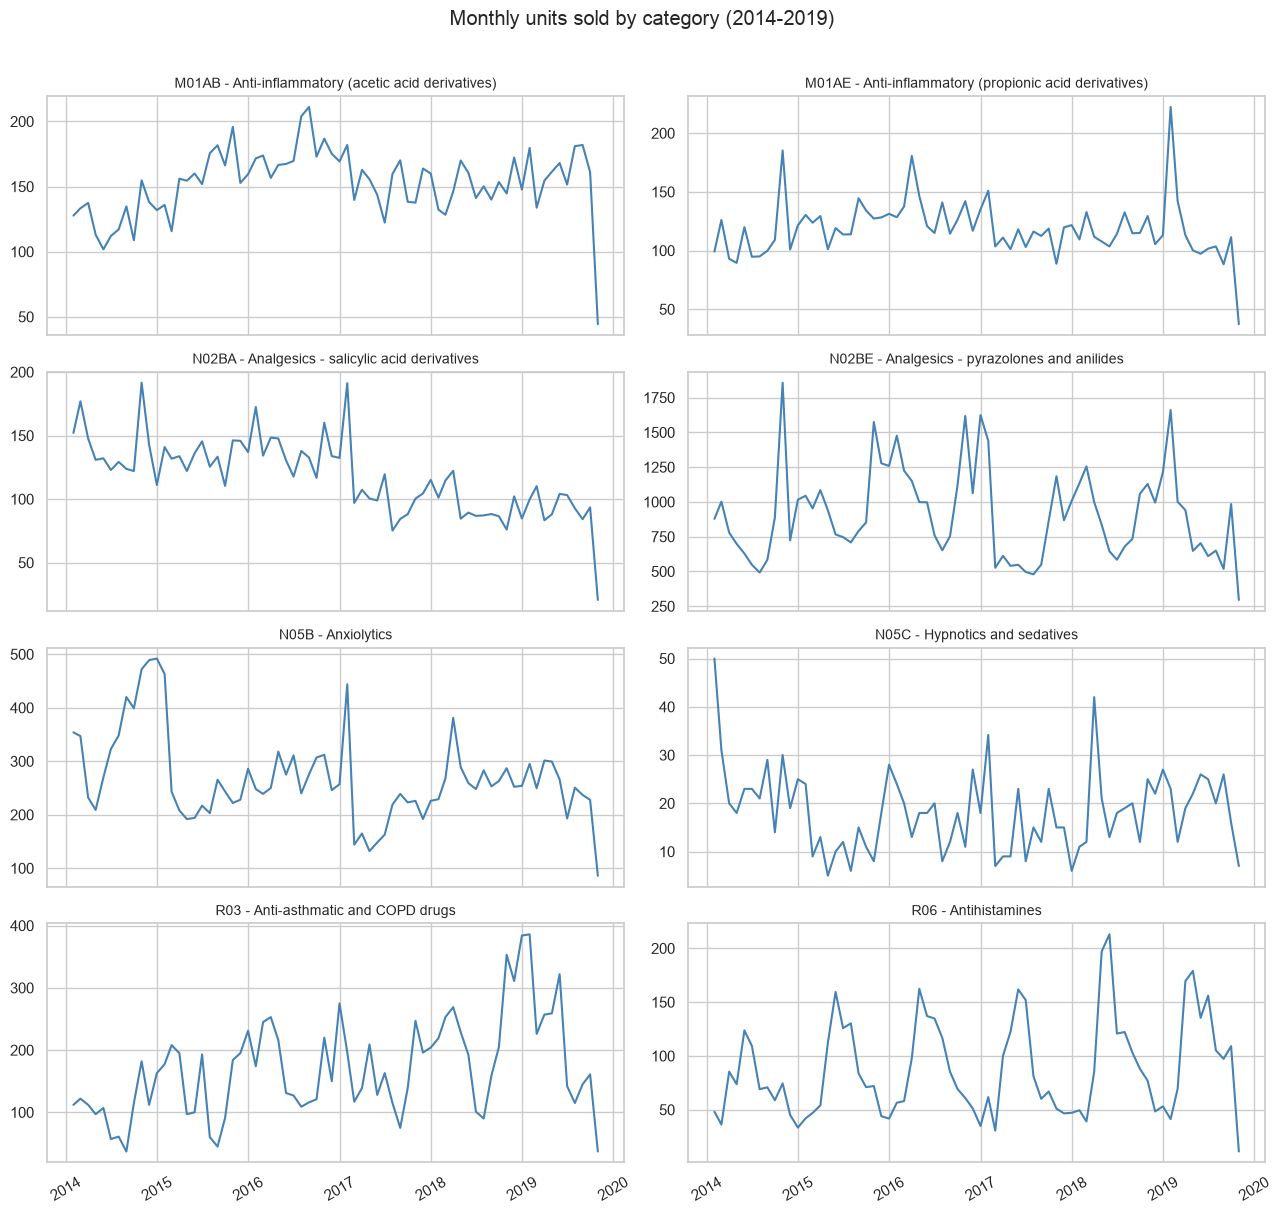

In [4]:
codes = sorted(monthly["category_code"].unique())
fig, axes = plt.subplots(4, 2, figsize=(13, 12), sharex=True)

for ax, code in zip(axes.flat, codes):
    sub = monthly[monthly["category_code"] == code]
    ax.plot(sub["sale_date"], sub["units_sold"], color="steelblue")
    ax.set_title(f"{code} - {CODE_TO_NAME[code]}", fontsize=10)
    ax.tick_params(axis="x", rotation=30)

fig.suptitle("Monthly units sold by category (2014-2019)", y=1.01)
fig.tight_layout()
fig.savefig(IMAGES_DIR / "monthly_trend.png", dpi=150, bbox_inches="tight")
plt.show()

**Finding: the last month (October 2019) is a partial month, not a real drop.** Every category shows a sharp fall on the last data point. The daily/hourly source files stop on 2019-10-08, so October's monthly total only covers 8 of 31 days — e.g. M01AB's October total (44.4) is roughly a quarter of September's (161.1), consistent with ~26% of the month being present, not an actual demand collapse. Notebooks 03-06 should drop or explicitly re-normalize October 2019 before fitting any model, otherwise it will be read as a trend break.

## Seasonality: month-of-year distribution

Distribution of each category's monthly sales grouped by calendar month, across all 6 years, to check for recurring within-year seasonality independent of the long-run trend.

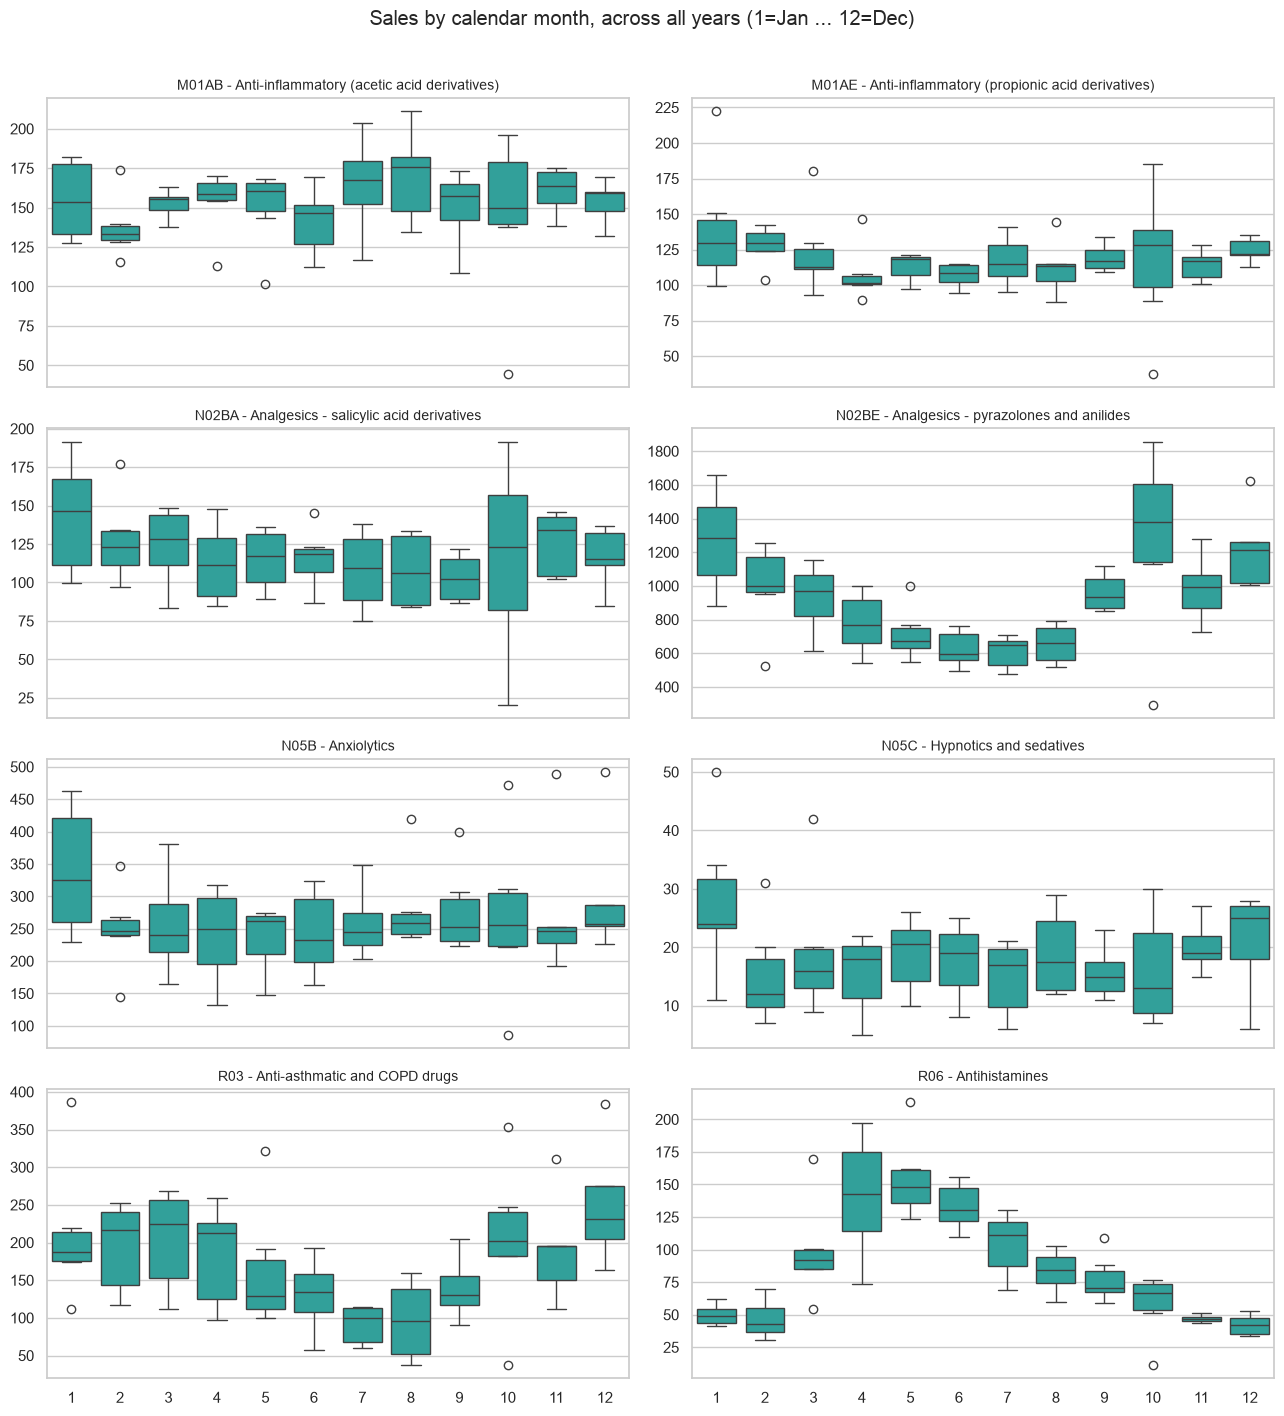

In [5]:
monthly["month_num"] = monthly["sale_date"].dt.month

fig, axes = plt.subplots(4, 2, figsize=(13, 14), sharex=True)
for ax, code in zip(axes.flat, codes):
    sub = monthly[monthly["category_code"] == code]
    sns.boxplot(data=sub, x="month_num", y="units_sold", ax=ax, color="lightseagreen")
    ax.set_title(f"{code} - {CODE_TO_NAME[code]}", fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")

fig.suptitle("Sales by calendar month, across all years (1=Jan ... 12=Dec)", y=1.01)
fig.tight_layout()
fig.savefig(IMAGES_DIR / "seasonality_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

**Finding: clear, category-specific seasonality.** R03 (anti-asthmatic/COPD) peaks in the winter months (Oct-Jan) and troughs in summer (Jun-Aug) — consistent with respiratory conditions worsening in cold weather. R06 (antihistamines) peaks Apr-Jun and is lowest Nov-Jan — consistent with spring/summer allergy season. These aren't small effects (R03's winter median is roughly double its summer median), which is a strong case for `SARIMA`/Holt-Winters with a 12-month seasonal period over a non-seasonal model in notebook 04.

## Weekday pattern

Uses the daily granularity, weekday derived from `sale_date` directly (not the raw file's `Weekday Name` column, to keep this independent of a column that was dropped during the melt in notebook 01).

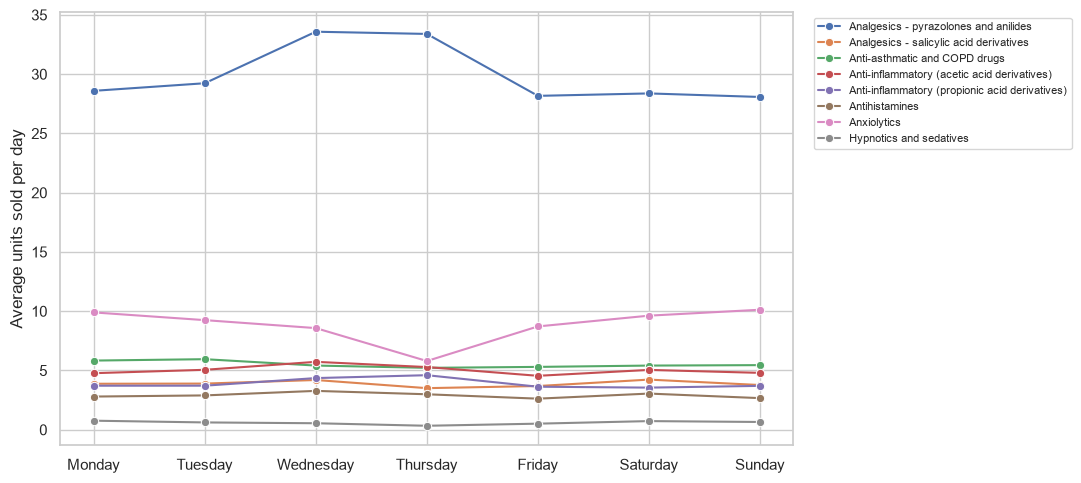

In [6]:
daily["weekday"] = daily["sale_date"].dt.day_name()
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

weekday_avg = (
    daily.groupby(["weekday", "category_name"])["units_sold"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 5))
sns.lineplot(
    data=weekday_avg, x="weekday", y="units_sold", hue="category_name",
    marker="o", ax=ax, sort=False
)
ax.set_xticks(range(len(weekday_order)))
ax.set_xticklabels(weekday_order)
ax.set_ylabel("Average units sold per day")
ax.set_xlabel("")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
fig.tight_layout()
fig.savefig(IMAGES_DIR / "weekday_pattern.png", dpi=150, bbox_inches="tight")
plt.show()

## Hour-of-day pattern

Same idea using the hourly granularity, aggregated across all categories (pharmacy opening-hours effect should dominate here rather than category-specific behavior).

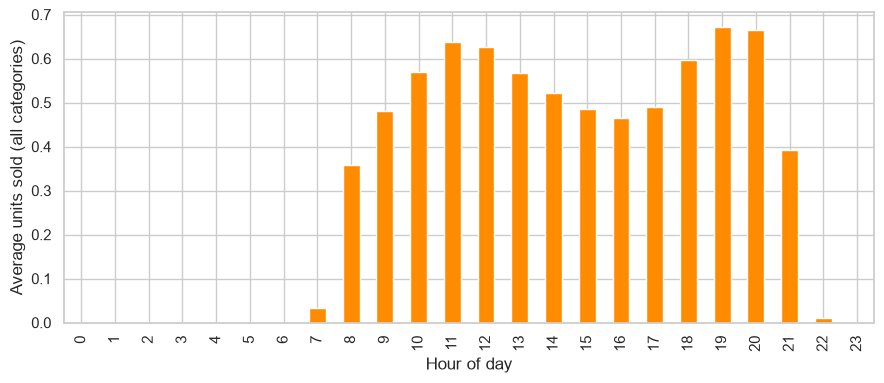

In [7]:
hourly["hour"] = hourly["sale_date"].dt.hour
hour_avg = hourly.groupby("hour")["units_sold"].mean()

fig, ax = plt.subplots(figsize=(9, 4))
hour_avg.plot(kind="bar", ax=ax, color="darkorange")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Average units sold (all categories)")
fig.tight_layout()
plt.show()

## Missing calendar dates

Checks whether the daily file actually has one row per calendar day across its full range, or whether some dates are silently absent (different from a reported value of 0).

In [8]:
full_range = pd.date_range(daily["sale_date"].min(), daily["sale_date"].max(), freq="D")
present_dates = pd.DatetimeIndex(daily["sale_date"].unique())
missing_dates = full_range.difference(present_dates)

print(f"expected days: {len(full_range)}, present days: {len(present_dates)}, missing: {len(missing_dates)}")
missing_dates

expected days: 2106, present days: 2106, missing: 0


DatetimeIndex([], dtype='datetime64[us]', freq='D')

No missing calendar dates in the daily file (2,106 expected, 2,106 present) — every day has a row, so any zero values are reported zeros, not silently absent data.

## Outlier days

IQR-based outlier flagging per category on the daily series, since daily is granular enough to expose spikes/drops that get smoothed out at the monthly level.

In [9]:
def flag_outliers(group):
    q1, q3 = group["units_sold"].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    group = group.copy()
    group["is_outlier"] = (group["units_sold"] < lower) | (group["units_sold"] > upper)
    return group

daily_flagged = daily.groupby("category_code", group_keys=False)[["sale_date", "category_code", "category_name", "units_sold"]].apply(flag_outliers)

outlier_summary = (
    daily_flagged.groupby("category_name")["is_outlier"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "n_outlier_days", "count": "n_days"})
)
outlier_summary["pct_outlier_days"] = (100 * outlier_summary["n_outlier_days"] / outlier_summary["n_days"]).round(2)
outlier_summary.sort_values("pct_outlier_days", ascending=False)

,n_outlier_days,n_days,pct_outlier_days
category_name,,,
Hypnotics and sedatives,160,2106,7.60
Anti-asthmatic and COPD drugs,124,2106,5.89
Antihistamines,81,2106,3.85
Analgesics - pyrazolones and anilides,48,2106,2.28
Anxiolytics,48,2106,2.28
Anti-inflammatory (propionic acid derivatives),40,2106,1.90
Analgesics - salicylic acid derivatives,31,2106,1.47
Anti-inflammatory (acetic acid derivatives),26,2106,1.23


In [10]:
daily_flagged[daily_flagged["is_outlier"]].sort_values("units_sold", ascending=False).head(10)

,sale_date,category_code,category_name,units_sold,is_outlier
8750,2016-12-30,N02BE,Analgesics - pyrazolones and anilides,161.00,True
8752,2016-12-31,N02BE,Analgesics - pyrazolones and anilides,108.70,True
14812,2019-01-27,N02BE,Analgesics - pyrazolones and anilides,100.10,True
14807,2019-01-26,N02BE,Analgesics - pyrazolones and anilides,97.80,True
14756,2019-01-20,N02BE,Analgesics - pyrazolones and anilides,93.05,True
8146,2016-10-16,N02BE,Analgesics - pyrazolones and anilides,89.30,True
8090,2016-10-09,N02BE,Analgesics - pyrazolones and anilides,88.40,True
5898,2016-01-09,N02BE,Analgesics - pyrazolones and anilides,88.30,True
6134,2016-02-07,N02BE,Analgesics - pyrazolones and anilides,88.20,True
5790,2015-12-26,N02BE,Analgesics - pyrazolones and anilides,87.20,True


N05C (lowest-volume category) has the highest outlier rate at 7.6% of days, which tracks with it having the smallest base volume — a handful of extra units reads as a large relative swing. N02BE's largest outlier days cluster around late December and late January across multiple years, plausibly flu/cold-season demand spikes rather than data errors, worth keeping in mind before automatically capping or removing them in later notebooks.

## Cross-category correlation

Do different drug categories move together month to month, using weekly data for more points than monthly gives (302 vs 70).

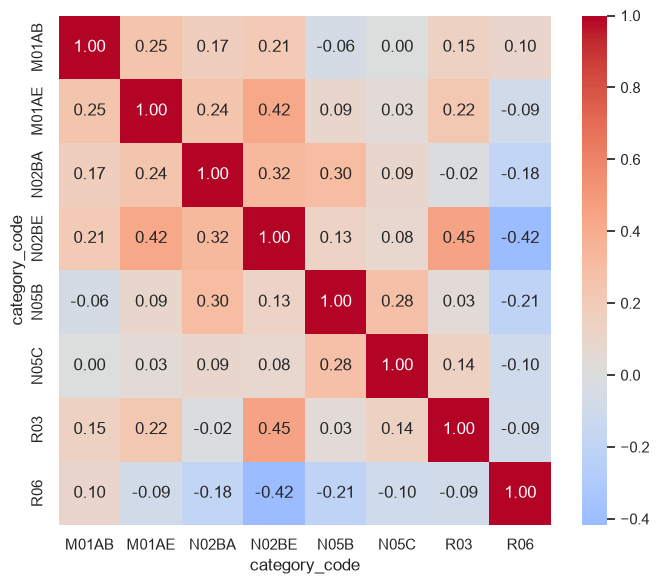

In [11]:
weekly_wide = weekly.pivot(index="sale_date", columns="category_code", values="units_sold")
corr = weekly_wide.corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
fig.tight_layout()
fig.savefig(IMAGES_DIR / "category_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

**Finding:** N02BE (analgesics) and R03 (respiratory) correlate at +0.45 — plausibly co-driven by flu/cold season. N02BE and R06 (antihistamines) correlate at -0.42, consistent with the seasonality finding above: R03/analgesics run high in winter while R06/antihistamines run high in spring, so they're structurally out of phase rather than independent. No pair is highly collinear (all \\|r\\| < 0.5), so there's no redundancy risk in modeling each category as a separate series.

In [12]:
conn.close()